# Compositional Analogical Transfer

Classical AI models (MLP, RNN, SINDy) learn global models with a fixed input size, making them unable to generalize to systems of different sizes.

We propose to learn a **local interaction rule** on a small system, then apply it to every connection of a larger system (compositional analogical transfer). We validate the method on mechanical pendulums, quantum spin chains, synaptic plasticity, and fish schools.

---

<details>
<summary><b>🇫🇷 Version française</b></summary>

Les IA classiques apprennent des modèles globaux à taille fixe, incapables de généraliser à des systèmes de taille différente.

Nous proposons d’apprendre une **règle d’interaction locale** sur un petit système, puis de l’appliquer à chaque connexion d’un système plus grand (transfert analogique compositionnel). Nous validons la méthode sur des pendules mécaniques, des chaînes de spins quantiques, la plasticité synaptique et des bancs de poissons.

</details>

## 0. Imports

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.integrate import solve_ivp
from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from sklearn.linear_model import TheilSenRegressor
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import os
os.makedirs('../figures', exist_ok=True)


## 1. Nonlinear Coupled Pendulums


The system consists of coupled pendulums evolving under gravity and linear nearest-neighbor coupling. The equation of motion for pendulum $i$ is:

$$ \ddot{\theta}_i = -\frac{g}{L}\,\sin(\theta_i) + k\,(\theta_{i-1} - \theta_i) + k\,(\theta_{i+1} - \theta_i) $$

where $g$ is gravity, $L$ the length, and $k$ the coupling constant. We aim to learn the local rule  $\text{coupling} = k\,(\theta_j - \theta_i)$ from a small system (2 pendulums) and generalize it to a larger system.

<details> <summary><b>🇫🇷 Version française</b></summary>
Le système est constitué de pendules couplés évoluant sous l’effet de la gravité et d’un couplage linéaire entre voisins. L’équation du mouvement pour le pendule $i$ est :

$$ \ddot{\theta}_i = -\frac{g}{L}\,\sin(\theta_i) + k\,(\theta_{i-1} - \theta_i) + k\,(\theta_{i+1} - \theta_i) $$

où $g$ est la gravité, $L$ la longueur, et $k$ la constante de couplage. L’objectif est d’apprendre la règle locale $\text{couplage} = k\,(\theta_j - \theta_i)$ à partir d’un petit système (2 pendules) puis de la généraliser à un système plus grand.
</details>

### 1.1. Parameters

In [33]:
# Physical parameters
g = 9.81          # gravity (m/s²)
L = 1.0           # length (m)
k_true = 0.5      # true coupling coefficient
g_over_L = g / L

# Time parameters
dt_eval = 0.05
t_span = (0, 20)
t_eval = np.arange(t_span[0], t_span[1], dt_eval)

# Noise and random seed
noise_std = 0.1
np.random.seed(42)

### 1.2. Training Data Generation (2 pendulums)


In [34]:
# Exact (nonlinear) model
def nonlinear_pendulum(t, y, k):
    n = len(y) // 2
    theta = y[:n]
    omega = y[n:]
    dtheta = omega.copy()
    domega = np.zeros(n)
    for i in range(n):
        domega[i] = -g_over_L * np.sin(theta[i])
        if i > 0:
            domega[i] += k * (theta[i-1] - theta[i])
        if i < n-1:
            domega[i] += k * (theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

# Initial conditions
y0_src = np.array([0.6, 0.9, 0.0, 0.0])

# Exact simulation
sol_src = solve_ivp(nonlinear_pendulum, t_span, y0_src,
                    args=(k_true,), t_eval=t_eval, method='DOP853',
                    rtol=1e-10, atol=1e-12)

theta1_exact = sol_src.y[0]
theta2_exact = sol_src.y[1]
omega2_exact = sol_src.y[3]

# Add noise
theta1_obs = theta1_exact + np.random.normal(0, noise_std, len(theta1_exact))
theta2_obs = theta2_exact + np.random.normal(0, noise_std, len(theta2_exact))
omega2_obs = omega2_exact + np.random.normal(0, noise_std, len(omega2_exact))

# Smoothing and derivative of omega2
window = 11
polyorder = 3
alpha2_obs = savgol_filter(omega2_obs, window, polyorder,
                           deriv=1, delta=dt_eval)
theta2_smooth = savgol_filter(theta2_obs, window, polyorder)

# Observed coupling = α + (g/L) sin(θ)
couplage_obs = alpha2_obs + g_over_L * np.sin(theta2_smooth)

# SNR (= signal to noise ratio) diagnostic
snr = np.var(theta1_exact - theta2_exact) / (2 * noise_std**2)
print(f"SNR(Δθ) = {snr:.1f}  (noise = {100/(1+snr):.1f}%)")

SNR(Δθ) = 5.7  (noise = 14.9%)


### 1.3. Learning the Local Rule

In [35]:
X_train = (theta1_obs - theta2_obs).reshape(-1, 1)
y_train = couplage_obs

reg = TheilSenRegressor(fit_intercept=False, random_state=42)
reg.fit(X_train, y_train)
k_est = reg.coef_[0]
intercept = reg.intercept_

print(f"Learned rule: coupling = {k_est:.4f} * Δθ + {intercept:.4f}")
print(f"True value: k = {k_true:.4f}, intercept = 0")
print(f"Relative error on k: {100*abs(k_est-k_true)/k_true:.1f}%")

Learned rule: coupling = 0.4952 * Δθ + 0.0000
True value: k = 0.5000, intercept = 0
Relative error on k: 1.0%


**Note:** *The Theil-Sen estimator is used instead of ordinary least squares because it remains robust to outliers that may persist after smoothing.*

<details> <summary><b>🇫🇷 Version française</b></summary>
<b>Note :</b> <i>L’estimateur de Theil‑Sen (TheilSenRegressor) est utilisé par rapport à une régression linéaire classique car il reste robuste face aux outliers qui peuvent subsister après le lissage.</i>
</details>

### 1.4. Generalisation to N Pendulums

In [36]:
# Number of target pendulums
N = 10

# Initial conditions for N pendulums (increasing angles)
angles_init = np.linspace(0.5, 0.9, N)
y0_cib = np.concatenate([angles_init, np.zeros(N)])

# Target system with learned rule
def model_pendulum(t, y, k, intercept):
    n = len(y) // 2
    theta = y[:n]
    omega = y[n:]
    dtheta = omega.copy()
    domega = np.zeros(n)
    for i in range(n):
        domega[i] = -g_over_L * np.sin(theta[i]) + intercept
        if i > 0:
            domega[i] += k * (theta[i-1] - theta[i])
        if i < n-1:
            domega[i] += k * (theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

# Simulation with learned rule
sol_transfert = solve_ivp(model_pendulum, t_span, y0_cib,
                          args=(k_est, intercept), t_eval=t_eval,
                          method='DOP853', rtol=1e-8, atol=1e-10)

# Exact reference simulation
sol_exact = solve_ivp(nonlinear_pendulum, t_span, y0_cib,
                      args=(k_true,), t_eval=t_eval,
                      method='DOP853', rtol=1e-10, atol=1e-12)

theta_model = sol_transfert.y[:N].T
theta_exact  = sol_exact.y[:N].T

### 1.5. Évaluation

In [37]:
print(f"Results (target system with {N} pendulums)")
for i in range(N):
    corr = np.corrcoef(theta_model[:,i], theta_exact[:,i])[0,1]
    rmse = np.sqrt(np.mean((theta_model[:,i] - theta_exact[:,i])**2))
    print(f" Pendulum {i+1}: correlation = {corr:.4f},  RMSE = {rmse:.4f} rad")

amp_exact = (theta_exact[:,1].max() - theta_exact[:,1].min()) / 2
amp_model = (theta_model[:,1].max() - theta_model[:,1].min()) / 2
err_amp = 100 * abs(amp_model - amp_exact) / amp_exact
print(f"\nCentral amplitude: exact = {amp_exact:.4f} rad, model = {amp_model:.4f} rad \nError {err_amp:.1f}%")

# Robustness test
print("\n\nRobustness test (same k_true, increasing noise):")
for ns in [0.01, 0.05, 0.1, 0.15, 0.2]:
    np.random.seed(42)
    theta1_n = theta1_exact + np.random.normal(0, ns, len(theta1_exact))
    theta2_n = theta2_exact + np.random.normal(0, ns, len(theta2_exact))
    omega2_n = omega2_exact + np.random.normal(0, ns, len(omega2_exact))
    alpha2_n = savgol_filter(omega2_n, window, polyorder, deriv=1, delta=dt_eval)
    theta2_n_smooth = savgol_filter(theta2_n, window, polyorder)
    couplage_n = alpha2_n + g_over_L * np.sin(theta2_n_smooth)
    X_n = (theta1_n - theta2_n).reshape(-1, 1)
    reg_n = TheilSenRegressor(fit_intercept=False, random_state=42)
    reg_n.fit(X_n, couplage_n)
    err = 100 * abs(reg_n.coef_[0] - k_true) / k_true
    print(f"  noise_std={ns:.2f} → k_est={reg_n.coef_[0]:.4f}, error={err:.1f}%")

# Statistical robustness (50 random seeds, noise=0.01)
print("\n\nStatistical robustness (noise_std=0.01, 50 random seeds):")
k_estimates = []
for seed in range(50):
    np.random.seed(seed)
    t1_n = theta1_exact + np.random.normal(0, 0.01, len(theta1_exact))
    t2_n = theta2_exact + np.random.normal(0, 0.01, len(theta2_exact))
    o2_n = omega2_exact + np.random.normal(0, 0.01, len(omega2_exact))
    a2_n = savgol_filter(o2_n, window, polyorder, deriv=1, delta=dt_eval)
    t2_l = savgol_filter(t2_n, window, polyorder)
    c_n  = a2_n + g_over_L * np.sin(t2_l)
    X_n  = (t1_n - t2_n).reshape(-1, 1)
    r_n  = TheilSenRegressor(fit_intercept=False, random_state=seed)
    r_n.fit(X_n, c_n)
    k_estimates.append(r_n.coef_[0])

k_estimates = np.array(k_estimates)
print(f"noise_std=0.01 over 50 seeds:")
print(f"  k = {k_estimates.mean():.4f} ± {k_estimates.std():.4f}")
print(f"  95% CI: [{np.percentile(k_estimates,2.5):.4f}, {np.percentile(k_estimates,97.5):.4f}]")


np.random.seed(42)

Results (target system with 10 pendulums)
 Pendulum 1: correlation = 1.0000,  RMSE = 0.0002 rad
 Pendulum 2: correlation = 1.0000,  RMSE = 0.0002 rad
 Pendulum 3: correlation = 1.0000,  RMSE = 0.0003 rad
 Pendulum 4: correlation = 1.0000,  RMSE = 0.0002 rad
 Pendulum 5: correlation = 1.0000,  RMSE = 0.0001 rad
 Pendulum 6: correlation = 1.0000,  RMSE = 0.0002 rad
 Pendulum 7: correlation = 1.0000,  RMSE = 0.0003 rad
 Pendulum 8: correlation = 1.0000,  RMSE = 0.0003 rad
 Pendulum 9: correlation = 1.0000,  RMSE = 0.0003 rad
 Pendulum 10: correlation = 1.0000,  RMSE = 0.0007 rad

Central amplitude: exact = 0.5437 rad, model = 0.5437 rad 
Error 0.0%


Robustness test (same k_true, increasing noise):
  noise_std=0.01 → k_est=0.5034, error=0.7%
  noise_std=0.05 → k_est=0.5222, error=4.4%
  noise_std=0.10 → k_est=0.4952, error=1.0%
  noise_std=0.15 → k_est=0.3981, error=20.4%
  noise_std=0.20 → k_est=0.2853, error=42.9%


Statistical robustness (noise_std=0.01, 50 random seeds):
noise_std=0.0

### 1.6. Visualisation

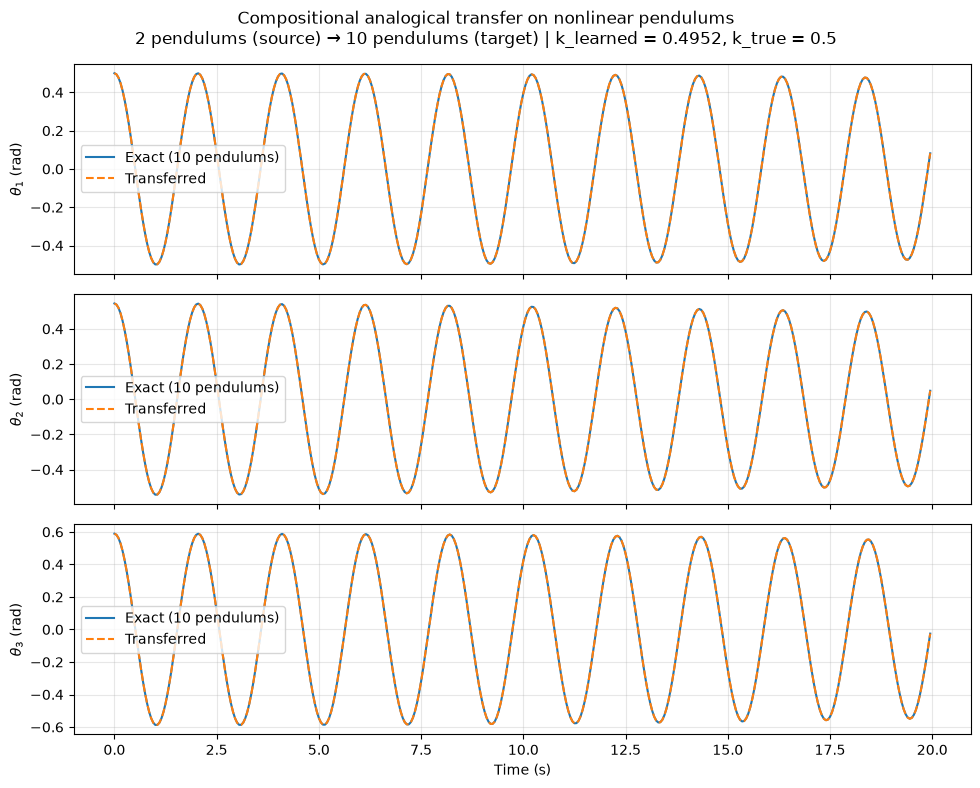

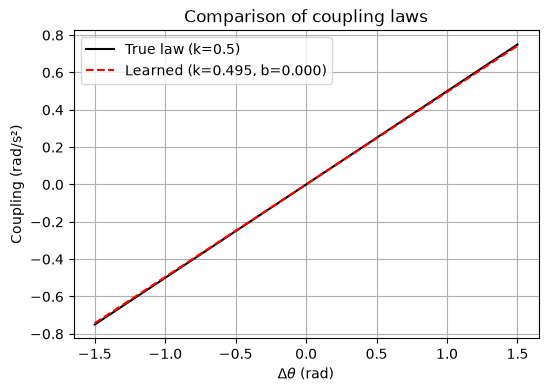

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t_eval, theta_exact[:, i], label=f'Exact ({N} pendulums)', lw=1.5)
    ax.plot(t_eval, theta_model[:, i], '--', label='Transferred', lw=1.5)
    ax.set_ylabel(f'$\\theta_{i+1}$ (rad)')
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Compositional analogical transfer on nonlinear pendulums\n'
             f'2 pendulums (source) → {N} pendulums (target) | '
             f'k_learned = {k_est:.4f}, k_true = {k_true}')
plt.tight_layout()
plt.savefig('../figures/nonlinear_transfer.png', dpi=150)
plt.show()

# Comparison of coupling laws
delta = np.linspace(-1.5, 1.5, 200)
plt.figure(figsize=(6,4))
plt.plot(delta, k_true * delta, 'k-', label=f'True law (k={k_true})')
plt.plot(delta, k_est * delta + intercept, 'r--',
         label=f'Learned (k={k_est:.3f}, b={intercept:.3f})')
plt.xlabel('$\\Delta\\theta$ (rad)'); plt.ylabel('Coupling (rad/s²)')
plt.legend(); plt.grid(True)
plt.title('Comparison of coupling laws')
plt.savefig('../figures/coupling_law.png', dpi=150)
plt.show()

## 2. Quantum Spin Chain (Ising Model)

After validating the approach on a classical system (pendulums), we show that it naturally extends to the quantum domain, here a chain of spins coupled according to the Ising model.

The system is a chain of $N$ spin 1/2 particles with Ising interactions and a transverse field. The Hamiltonian is:

$$ H = -J \sum_{i=1}^{N-1} \sigma^z_i \sigma^z_{i+1} - h \sum_{i=1}^{N} \sigma^x_i $$

where $\sigma^x_i$, $\sigma^z_i$ are Pauli matrices acting on spin $i$. We aim to learn the local parameters $J$ and $h$ from random state sampling of a small chain (3 spins), then use this rule to predict the energy of a larger chain (10 spins) without full simulation.

<details>
<summary><b>🇫🇷 Version française</b></summary>

Après avoir validé l’approche sur un système classique (les pendules), nous montrons qu’elle s’étend naturellement au domaine quantique, ici une chaîne de spins couplés selon le modèle d’Ising.

Le système est une chaîne de $N$ spins 1/2 couplés par une interaction de type Ising et soumis à un champ transverse. L’hamiltonien s’écrit :

$$ H = -J \sum_{i=1}^{N-1} \sigma^z_i \sigma^z_{i+1} - h \sum_{i=1}^{N} \sigma^x_i $$

où $\sigma^x_i$, $\sigma^z_i$ sont les matrices de Pauli agissant sur le $i$-ème spin. L’objectif est d’apprendre les paramètres locaux $J$ et $h$ à partir de l’échantillonnage aléatoire d’états d’une petite chaîne (3 spins), puis d’utiliser cette règle pour prédire l’énergie d’une chaîne plus grande (10 spins) sans la simuler intégralement.

</details>

### 2.1. Parameters


In [39]:
# Physical parameters
J_true = 1.0          # Ising coupling strength
h_true = 1.0          # transverse field
N_train = 3           # source system size (for training)
N_target = 10         # target system size (for transfer)

# Time parameters
dt = 0.1
T = 10.0
times = np.arange(0, T, dt)

# Measurement noise (std on observables)
noise_std = 0.10
np.random.seed(42)

# Number of random states for training
n_samples = 2000
n_test = 200

### 2.2. Operators, Hamiltonian Construction and Training Data Generation

In [40]:
# Pauli matrices
sx = np.array([[0., 1.], [1., 0.]])
sy = np.array([[0., -1j], [1j, 0.]])
sz = np.array([[1., 0.], [0., -1.]])
I2 = np.eye(2)

def kron_n(*mats):
    res = mats[0]
    for m in mats[1:]:
        res = np.kron(res, m)
    return res

def build_hamiltonian(N, J, h):
    H = np.zeros((2**N, 2**N), dtype=complex)
    # Interaction term (neighbors)
    for i in range(N-1):
        op_list = [I2]*N
        op_list[i] = sz
        op_list[i+1] = sz
        H += -J * kron_n(*op_list)
    # Transverse field
    for i in range(N):
        op_list = [I2]*N
        op_list[i] = sx
        H += -h * kron_n(*op_list)
    return H

def build_operators(N):
    ops_zz = []
    ops_x = []
    for i in range(N-1):
        op_list = [I2]*N
        op_list[i] = sz
        op_list[i+1] = sz
        ops_zz.append(kron_n(*op_list))
    for i in range(N):
        op_list = [I2]*N
        op_list[i] = sx
        ops_x.append(kron_n(*op_list))
    return ops_zz, ops_x

ops_zz_train, ops_x_train = build_operators(N_train)
ops_zz_target, ops_x_target = build_operators(N_target)

def local_expectations(psi, ops_zz, ops_x):
    zz_sum = 0.0
    x_sum = 0.0
    for M in ops_zz:
        zz_sum += np.real(psi.conj().T @ M @ psi)
    for M in ops_x:
        x_sum += np.real(psi.conj().T @ M @ psi)
    return zz_sum, x_sum

H3 = build_hamiltonian(N_train, J_true, h_true)
d = 2**N_train

X_train = []
y_train = []
for _ in range(n_samples):
    # Random complex normalized state
    psi = np.random.randn(d) + 1j * np.random.randn(d)
    psi /= np.linalg.norm(psi)
    zz, xx = local_expectations(psi, ops_zz_train, ops_x_train)
    energy = np.real(psi.conj().T @ H3 @ psi)
    X_train.append([zz, xx])
    y_train.append(energy)

X_train = np.array(X_train)
y_train = np.array(y_train)
print(f"Training data generated: {n_samples} states.")

Training data generated: 2000 states.


### 2.3. Learning the Local Rule

In [41]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)
J_est = -model.coef_[0]    # car α ≈ -J
h_est = -model.coef_[1]    # car β ≈ -h
intercept = model.intercept_

print("Learned rule:")
print(f"  E = {model.coef_[0]:.4f} * ZZ_sum + {model.coef_[1]:.4f} * X_sum + {intercept:.4f}")
print(f"Exact values: J = {J_true:.4f} (α expected = {-J_true:.4f}), h = {h_true:.4f} (β expected = {-h_true:.4f})")
print(f"Error on J: {100*abs(J_est - J_true)/J_true:.2f}%")
print(f"Error on h: {100*abs(h_est - h_true)/h_true:.2f}%")

Learned rule:
  E = -1.0000 * ZZ_sum + -1.0000 * X_sum + -0.0000
Exact values: J = 1.0000 (α expected = -1.0000), h = 1.0000 (β expected = -1.0000)
Error on J: 0.00%
Error on h: 0.00%


### 2.4. Generalization to N Spins


In [42]:
print(f"\nBuilding Hamiltonian for {N_target} spins...")
H_target = build_hamiltonian(N_target, J_true, h_true)

# Test on n_test random states
errors = []
t0 = time.time()

for _ in range(n_test):
    psi = np.random.randn(2**N_target) + 1j * np.random.randn(2**N_target)
    psi /= np.linalg.norm(psi)

    zz, xx = local_expectations(psi, ops_zz_target, ops_x_target)
    energy_pred = model.predict([[zz, xx]])[0]
    energy_exact = np.real(psi.conj().T @ H_target @ psi)

    errors.append(abs(energy_exact - energy_pred))

t_elapsed = time.time() - t0

print(f"\nMean absolute error over {n_test} random states: {np.mean(errors):.4e}")
print(f"Mean relative error: {100 * np.mean(errors)/np.mean(np.abs(y_train)):.2f}%")
print(f"Execution time: {t_elapsed:.2f} s")


Building Hamiltonian for 10 spins...

Mean absolute error over 200 random states: 1.6353e-16
Mean relative error: 0.00%
Execution time: 34.64 s


### 2.5. Évaluation

In [43]:
print("\nRobustness to noise:")
for sigma in [0.0, 0.05, 0.10, 0.20]:
    X_noisy = X_train + np.random.normal(0, sigma, X_train.shape)
    model_noisy = LinearRegression().fit(X_noisy, y_train)
    J_noisy = -model_noisy.coef_[0]
    err_J = 100 * abs(J_noisy - J_true) / J_true
    print(f"  σ = {sigma:.2f} → J_est = {J_noisy:.4f}, error = {err_J:.1f}%")


Robustness to noise:
  σ = 0.00 → J_est = 1.0000, error = 0.0%
  σ = 0.05 → J_est = 0.9914, error = 0.9%
  σ = 0.10 → J_est = 0.9667, error = 3.3%
  σ = 0.20 → J_est = 0.8415, error = 15.8%


### 2.6. Visualisation


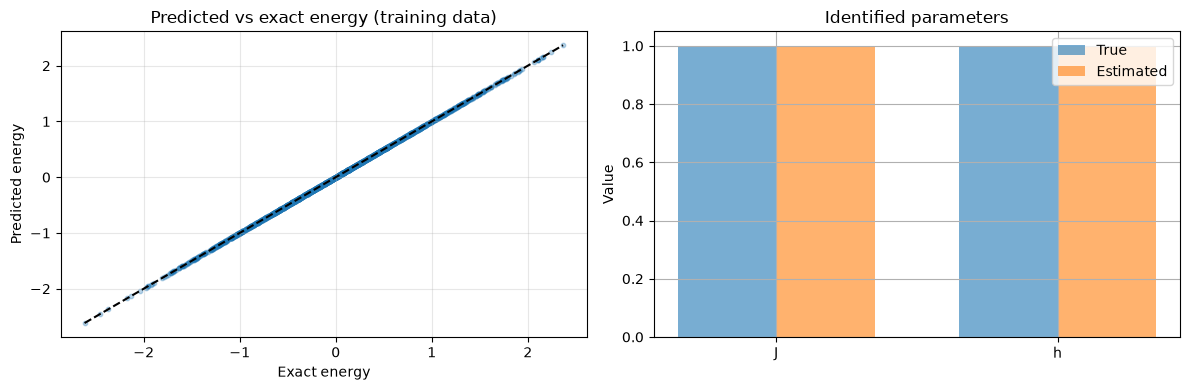

In [44]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(y_train, model.predict(X_train), alpha=0.3, s=10)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'k--', lw=1.5)
plt.xlabel('Exact energy')
plt.ylabel('Predicted energy')
plt.title('Predicted vs exact energy (training data)')
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
categories = ['J', 'h']
x = np.arange(len(categories))
width = 0.35

coeffs_true = np.array([J_true, h_true])
coeffs_est = np.array([J_est, h_est])

plt.bar(x - width/2, coeffs_true, width, alpha=0.6, label='True')
plt.bar(x + width/2, coeffs_est, width, alpha=0.6, label='Estimated')
plt.xticks(x, categories)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.title('Identified parameters')

plt.tight_layout()
plt.savefig('../figures/ising_transfer.png', dpi=150)
plt.show()

## 3. Synaptic Plasticity (Oja's Rule)


After exploring classical and quantum domains, we turn to a biological system: synaptic plasticity.

Synaptic plasticity follows Oja's rule, which describes the evolution of the weight $w_{ij}$ between a pre-synaptic neuron $j$ with activity $x_j$ and a post-synaptic neuron $i$ with activity $x_i$:

$$ \frac{dw_{ij}}{dt} = \eta\, x_i x_j - \eta\alpha\, w_{ij} $$

where $\eta$ is the learning rate and $\alpha$ the forgetting factor. We aim to identify $\eta$ and $\eta\alpha$ from a single connection (2 neurons) and then simulate the weight evolution in a network of 10 neurons.

<details>
<summary><b>🇫🇷 Version française</b></summary>

Après avoir exploré les domaines classique et quantique, nous nous tournons vers un système biologique : la plasticité synaptique.

La plasticité synaptique suit la règle d’Oja, qui décrit l’évolution du poids $w_{ij}$ entre un neurone pré‑synaptique $j$ d’activité $x_j$ et un neurone post‑synaptique $i$ d’activité $x_i$ :

$$ \frac{dw_{ij}}{dt} = \eta\, x_i x_j - \eta\alpha\, w_{ij} $$

où $\eta$ est le taux d’apprentissage et $\alpha$ le facteur d’oubli. Nous cherchons à identifier $\eta$ et $\eta\alpha$ à partir d’une seule connexion (2 neurones) puis à simuler l’évolution des poids dans un réseau de 10 neurones.

</details>

### 3.1. Parameters


In [45]:
# Time parameters
dt = 0.01
T = 50.0
time_neurons = np.arange(0, T + dt, dt)
n_steps = len(time_neurons)

# Oja rule parameters
eta = 0.1
alpha = 0.05

# Noise on activities
noise_activity = 0.02
np.random.seed(42)

### 3.2. Noisy Data Generation (2 neurons)

In [46]:
# Exact activities
x1_true = 0.5 + 0.3 * np.sin(2 * np.pi * 0.5 * time_neurons)
x2_true = 0.5 + 0.3 * np.sin(2 * np.pi * 0.5 * time_neurons + np.pi/4)

# Noisy measurements
x1_meas = np.clip(x1_true + np.random.normal(0, noise_activity, n_steps), 0, 1)
x2_meas = np.clip(x2_true + np.random.normal(0, noise_activity, n_steps), 0, 1)

### 3.3. Exact Synaptic Weight and Derivative



In [47]:
# Exact weight (computed from exact activities)
w_true = np.zeros(n_steps)
w_true[0] = 0.1
for i in range(1, n_steps):
    prod = x1_true[i-1] * x2_true[i-1]
    dw = eta * (prod - alpha * w_true[i-1])
    w_true[i] = w_true[i-1] + dw * dt

# Exact derivative dw/dt (target for learning)
dwdt_exact = np.zeros(n_steps)
for i in range(1, n_steps):
    prod_true = x1_true[i-1] * x2_true[i-1]
    dwdt_exact[i] = eta * (prod_true - alpha * w_true[i-1])


### 3.4. Learning the Rule


$Δw= \eta⋅(x_1 x_2)-\eta\alpha⋅w$

In [48]:
X_train = np.column_stack([x1_meas * x2_meas, w_true])
y_train = dwdt_exact

window = min(15, n_steps if n_steps % 2 == 1 else n_steps - 1)
if window >= 3:
    X_train[:, 0] = savgol_filter(X_train[:, 0], window_length=window, polyorder=3)
    y_train = savgol_filter(y_train, window_length=window, polyorder=3)

# Linear regression
model = LinearRegression()
model.fit(X_train, y_train)
k_prod, k_w = model.coef_
intercept = model.intercept_

print("Learned rule (noisy inputs):")
print(f"dw/dt = {k_prod:.4f}·(x_pre·x_post) + {k_w:.4f}·w + {intercept:.4f}")
print(f"True rule: dw/dt = {eta:.4f}·(x_pre·x_post) + {-eta*alpha:.4f}·w + 0.0000")
print(f"Error on η: {100*abs(k_prod - eta)/eta:.1f}%")
print(f"Error on ηα: {100*abs(k_w + eta*alpha)/abs(eta*alpha):.1f}%")

Learned rule (noisy inputs):
dw/dt = 0.1001·(x_pre·x_post) + -0.0049·w + -0.0001
True rule: dw/dt = 0.1000·(x_pre·x_post) + -0.0050·w + 0.0000
Error on η: 0.1%
Error on ηα: 2.5%


### 3.5. Generalization to a Network of N Neurons



In [49]:
N_neurons = 10

phases = np.linspace(0, 2*np.pi, N_neurons, endpoint=False)
x = np.zeros((n_steps, N_neurons))
for i in range(N_neurons):
    x[:, i] = 0.5 + 0.3 * np.sin(2 * np.pi * 0.5 * time_neurons + phases[i])
    x[:, i] = np.clip(x[:, i], 0, 1)

# Weight matrix initialization
W_exact = np.random.randn(N_neurons, N_neurons) * 0.05
W_appris = W_exact.copy()
np.fill_diagonal(W_exact, 0)
np.fill_diagonal(W_appris, 0)

# Track a specific connection
i_fix, j_fix = 0, 1
history_exact = []
history_appris = []
record_every = int(1/dt)

for t in range(1, n_steps):
    for i in range(N_neurons):
        for j in range(N_neurons):
            if i == j:
                continue
            prod = x[t-1, i] * x[t-1, j]
            # Exact rule
            dW_exact = eta * (prod - alpha * W_exact[i, j])
            # Learned rule
            dW_appris = k_prod * prod + k_w * W_appris[i, j] + intercept
            W_exact[i, j] += dW_exact * dt
            W_appris[i, j] += dW_appris * dt
    if t % record_every == 0:
        history_exact.append(W_exact.copy())
        history_appris.append(W_appris.copy())

time_plot = time_neurons[record_every::record_every]
w_exact_hist = [w[i_fix, j_fix] for w in history_exact]
w_appris_hist = [w[i_fix, j_fix] for w in history_appris]

err_rel = np.mean(np.abs(W_exact - W_appris)) / (np.mean(np.abs(W_exact)) + 1e-8)
print(f"\nMean relative error on weights ({N_neurons} neurons): {err_rel:.3%}")


Mean relative error on weights (10 neurons): 0.041%


### 3.6. Evaluation (error on $\eta$ and $\alpha$, weights evolution)



In [50]:
print("Quantitative evaluation:")
print(f"Error on η: {100*abs(k_prod - eta)/eta:.2f}%")
print(f"Error on ηα: {100*abs(k_w + eta*alpha)/abs(eta*alpha):.2f}%")
print(f"Mean relative error on weights: {err_rel:.3%}")

print("\nRobustness to noise on activities:")
for noise in [0.01, 0.05, 0.10, 0.20]:
    np.random.seed(42)
    x1_n = x1_true + np.random.normal(0, noise, n_steps)
    x2_n = x2_true + np.random.normal(0, noise, n_steps)
    x1_n = np.clip(x1_n, 0, 1)
    x2_n = np.clip(x2_n, 0, 1)
    X_n = np.column_stack([x1_n * x2_n, w_true])
    X_n[:, 0] = savgol_filter(X_n[:, 0], window, polyorder) if window >= 3 else X_n[:, 0]
    model_n = LinearRegression().fit(X_n, y_train)
    eta_n = model_n.coef_[0]
    alpha_n = -model_n.coef_[1] / model_n.coef_[0] if abs(model_n.coef_[0]) > 1e-8 else 0
    err_eta = 100 * abs(eta_n - eta) / eta
    print(f"  σ = {noise:.2f} → η = {eta_n:.4f}, error η = {err_eta:.1f}%")

Quantitative evaluation:
Error on η: 0.06%
Error on ηα: 2.52%
Mean relative error on weights: 0.041%

Robustness to noise on activities:
  σ = 0.01 → η = 0.1000, error η = 0.0%
  σ = 0.05 → η = 0.0999, error η = 0.1%
  σ = 0.10 → η = 0.0991, error η = 0.9%
  σ = 0.20 → η = 0.0984, error η = 1.6%


### 3.7. Visualisation

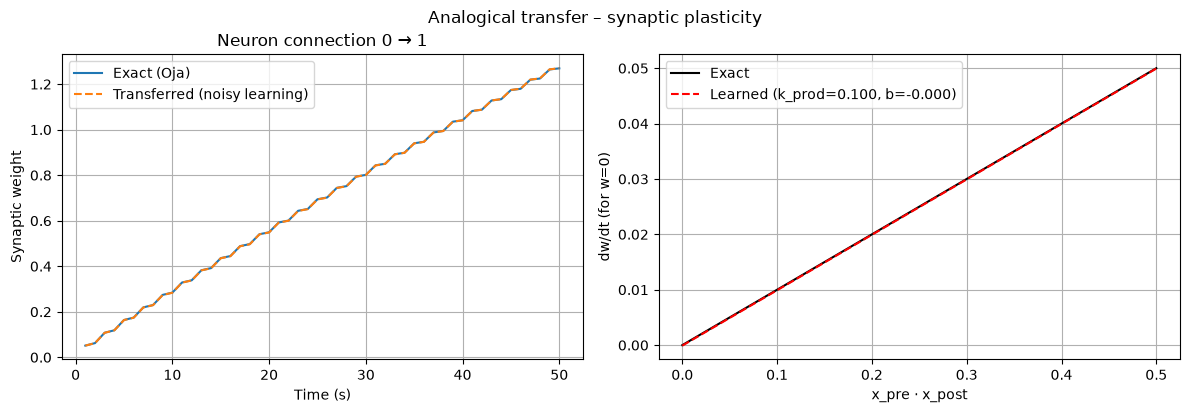

In [51]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(time_plot, w_exact_hist, label='Exact (Oja)', lw=1.5)
plt.plot(time_plot, w_appris_hist, '--', label='Transferred (noisy learning)', lw=1.5)
plt.xlabel('Time (s)')
plt.ylabel('Synaptic weight')
plt.title(f'Neuron connection {i_fix} → {j_fix}')
# Arbitrary choice of connection "0 → 1" for visualization.
# Any other pair would give similar results, as the learned rule is identical for all connections.
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
prod_range = np.linspace(0, 0.5, 100)
plt.plot(prod_range, eta * prod_range, 'k-', label='Exact', lw=1.5)
plt.plot(prod_range, k_prod * prod_range + intercept, 'r--',
         label=f'Learned (k_prod={k_prod:.3f}, b={intercept:.3f})', lw=1.5)
plt.xlabel('x_pre · x_post')
plt.ylabel('dw/dt (for w=0)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.suptitle('Analogical transfer – synaptic plasticity', y=1.02)
plt.savefig('../figures/plasticity_transfer.png', dpi=150)
plt.show()

## 4. Fish Schools (Reynolds Rules with Separation)


After exploring plasticity at the scale of a neural network, we turn to a more chaotic biological system: fish schools, whose emergent dynamics are governed by local nonlinear interactions.

Each fish adjusts its acceleration based on nearby neighbors according to three forces:

- **Cohesion**: $\mathbf{F}_{\text{coh}} = C \frac{1}{|N_i|} \sum_{j \in N_i} (\mathbf{p}_j - \mathbf{p}_i)$
- **Alignment**: $\mathbf{F}_{\text{alg}} = A \sum_{j} (\mathbf{v}_j - \mathbf{v}_i)$
- **Separation**: $\mathbf{F}_{\text{sep}} = S \sum_{j} \frac{\mathbf{p}_j - \mathbf{p}_i}{\|\mathbf{p}_j - \mathbf{p}_i\|^3}$ (if distance < threshold)

The local rule (vector sum of contributions) is learned on 8 fish and then applied to a school of 50 individuals.

<details>
<summary><b>🇫🇷 Version française</b></summary>

Après avoir exploré la plasticité à l’échelle d’un réseau de neurones, nous nous intéressons à un système biologique plus chaotique : les bancs de poissons, dont la dynamique émergente est régie par des interactions locales non linéaires.

Chaque poisson ajuste son accélération en fonction de ses voisins proches selon trois forces :

- <b>Cohésion</b> : $\mathbf{F}_{\text{coh}} = C \frac{1}{|N_i|} \sum_{j \in N_i} (\mathbf{p}_j - \mathbf{p}_i)$ (force proportionnelle à la distance au centre de masse du voisinage $N_i$)
- <b>Alignement</b> : $\mathbf{F}_{\text{alg}} = A \sum_{j} (\mathbf{v}_j - \mathbf{v}_i)$
- <b>Séparation</b> : $\mathbf{F}_{\text{sep}} = S \sum_{j} \frac{\mathbf{p}_j - \mathbf{p}_i}{\|\mathbf{p}_j - \mathbf{p}_i\|^3}$ (si distance < seuil)

La règle locale (somme vectorielle des contributions) est apprise sur 8 poissons puis appliquée à un banc de 50 individus.

</details>


### 4.1. Parameters



In [52]:
# Physical and time parameters
dt = 0.05
T_train = 40.0          # training duration
T_eval = 15.0           # evaluation duration

# Force strengths
cohesion_strength = 0.01
alignment_strength = 0.05
separation_strength = 0.1
separation_dist = 1.0
R_interaction = 2.5     # interaction radius

np.random.seed(42)

**Note:** *The simulation uses explicit loops for readability of the local rule. For larger systems, vectorization via Numpy (np.newaxis) or KD-Trees for neighbor search would optimize computation.*

<details> <summary><b>🇫🇷 Version française</b></summary>

<b>Note :</b> <i>La simulation utilise des boucles explicites pour maximiser la lisibilité de la règle locale. Pour de plus grands systèmes, une vectorisation via Numpy (np.newaxis) ou l'utilisation de KD-Trees pour la recherche de voisins optimiserait le calcul.</i>

</details>


### 4.2. Small School Simulation (8 fish)


In [53]:
n_small = 8 # number of fish for the training

# Exact Reynolds model with separation
def reynolds_acceleration(positions, vitesses, i):
    acc = np.zeros(2)
    center_mass = np.zeros(2)
    align_vel = np.zeros(2)
    separation = np.zeros(2)
    n_neigh = 0
    for j in range(len(positions)):
        if j == i:
            continue
        delta = positions[j] - positions[i]
        dist = np.linalg.norm(delta)
        if dist < R_interaction:
            n_neigh += 1
            center_mass += positions[j]
            align_vel += vitesses[j]
            if dist < separation_dist:
                separation -= delta / (dist**2 + 1e-8) * separation_strength
    if n_neigh > 0:
        center_mass = center_mass / n_neigh - positions[i]
        align_vel = align_vel / n_neigh - vitesses[i]
        acc += cohesion_strength * center_mass
        acc += alignment_strength * align_vel
    acc += separation
    return acc

def simulate(n_fish, duration, return_all=False):
    steps = int(duration/dt) + 1
    pos = np.zeros((steps, n_fish, 2))
    vel = np.zeros((steps, n_fish, 2))
    pos[0] = np.random.randn(n_fish, 2) * 2.0
    vel[0] = np.random.randn(n_fish, 2) * 0.5
    acc = np.zeros((steps, n_fish, 2)) if return_all else None
    for t in range(1, steps):
        for i in range(n_fish):
            a = reynolds_acceleration(pos[t-1], vel[t-1], i)
            vel[t, i] = vel[t-1, i] + a * dt
            pos[t, i] = pos[t-1, i] + vel[t-1, i] * dt
            if return_all:
                acc[t, i] = a
    return (pos, vel, acc) if return_all else (pos, vel)

print(f"Small school simulation ({n_small} fish) for training...")
pos_src, vel_src, acc_src = simulate(n_small, T_train, return_all=True)

# Feature construction (normalized by number of neighbors)
X_list, y_list = [], []
for t in range(1, pos_src.shape[0]):
    for i in range(n_small):
        sum_dpos = np.zeros(2)
        sum_dvel = np.zeros(2)
        sum_invdist = 0.0
        n_neigh = 0
        for j in range(n_small):
            if i == j:
                continue
            delta_pos = pos_src[t-1, j] - pos_src[t-1, i]
            dist = np.linalg.norm(delta_pos)
            if dist < R_interaction:
                n_neigh += 1
                sum_dpos += delta_pos
                sum_dvel += vel_src[t-1, j] - vel_src[t-1, i]
                sum_invdist += 1.0 / (dist + 1e-8)
        if n_neigh > 0:
            sum_dpos /= n_neigh
            sum_dvel /= n_neigh
            sum_invdist /= n_neigh
        # Features: relative position, velocity, and distance terms
        feat = np.concatenate([sum_dpos, sum_dvel, [sum_invdist], [sum_invdist**2]])
        X_list.append(feat)
        y_list.append(acc_src[t, i])

X = np.array(X_list)
y = np.array(y_list)

# Ridge regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = Ridge(alpha=0.01)
model.fit(X_scaled, y)
coeffs = model.coef_
intercept = model.intercept_

k_p_est = (abs(coeffs[0,0]) + abs(coeffs[1,1])) / 2
print(f"Estimated cohesion: {k_p_est:.4f} (theoretical {cohesion_strength:.4f}) → error {100*abs(k_p_est-cohesion_strength)/cohesion_strength:.1f}%")

Small school simulation (8 fish) for training...
Estimated cohesion: 0.0056 (theoretical 0.0100) → error 43.8%


**Note:** *Ridge regularization stabilizes the estimation in the presence of naturally correlated features (e.g., sums of position differences along x and y).*

<details> <summary><b>🇫🇷 Version française</b></summary>

<b>Note :</b><i> *La régularisation Ridge stabilise l’estimation en présence de caractéristiques naturellement corrélées (par exemple les sommes des différences de position selon x et y).</i>
</details>



### 4.3. Generalization to N > 8 Fish

In [54]:
N_large = 50 # number of fish for the transfer

def predict_acceleration(pos, vel, i):
    sum_dpos = np.zeros(2)
    sum_dvel = np.zeros(2)
    sum_invdist = 0.0
    n_neigh = 0
    for j in range(len(pos)):
        if i == j:
            continue
        delta_pos = pos[j] - pos[i]
        dist = np.linalg.norm(delta_pos)
        if dist < R_interaction:
            n_neigh += 1
            sum_dpos += delta_pos
            sum_dvel += vel[j] - vel[i]
            sum_invdist += 1.0 / (dist + 1e-8)
    if n_neigh > 0:
        sum_dpos /= n_neigh
        sum_dvel /= n_neigh
        sum_invdist /= n_neigh
    feat = np.concatenate([sum_dpos, sum_dvel, [sum_invdist], [sum_invdist**2]]).reshape(1, -1)
    feat_scaled = scaler.transform(feat)
    return model.predict(feat_scaled)[0]

def simulate_transfer(n_fish, duration, initial_pos=None, initial_vel=None):
    steps = int(duration/dt) + 1
    pos = np.zeros((steps, n_fish, 2))
    vel = np.zeros((steps, n_fish, 2))
    if initial_pos is None:
        pos[0] = np.random.randn(n_fish, 2) * 3.0
        vel[0] = np.random.randn(n_fish, 2) * 0.5
    else:
        pos[0] = initial_pos
        vel[0] = initial_vel
    for t in range(1, steps):
        for i in range(n_fish):
            acc = predict_acceleration(pos[t-1], vel[t-1], i)
            vel[t, i] = vel[t-1, i] + acc * dt
            pos[t, i] = pos[t-1, i] + vel[t-1, i] * dt
    return pos, vel

print(f"Exact large school ({N_large} fish) simulation for reference...")
np.random.seed(123)
pos_exact, vel_exact = simulate(N_large, T_eval)
np.random.seed(123)
pos_pred, vel_pred = simulate_transfer(N_large, T_eval,
                                       initial_pos=pos_exact[0],
                                       initial_vel=vel_exact[0])

Exact large school (50 fish) simulation for reference...


### 4.4. Comparative Animation

Generating comparative animation...
Animation saved: fish_comparison_final.gif


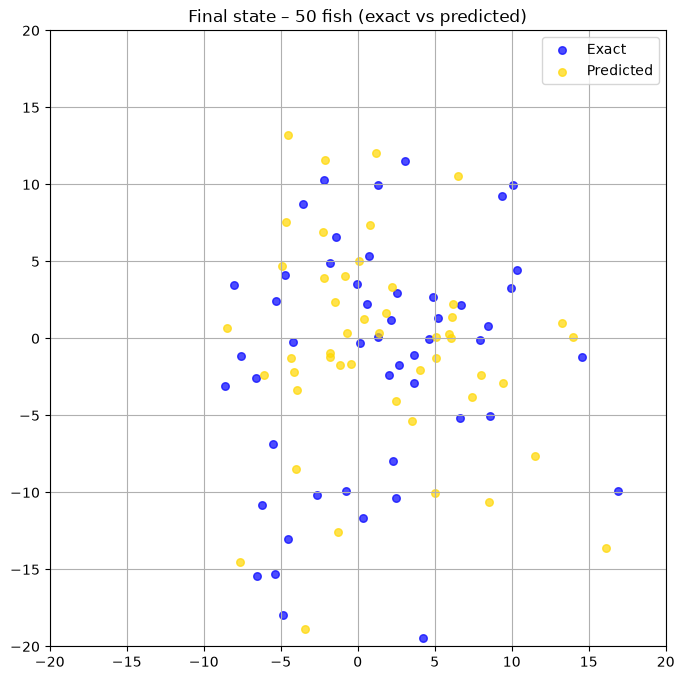

In [55]:
print("Generating comparative animation...")
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_aspect('equal')
ax.grid(True)
scat_exact = ax.scatter([], [], s=20, c='blue', alpha=0.7, label='Exact')
scat_pred = ax.scatter([], [], s=20, c='gold', alpha=0.7, label='Predicted')
ax.legend()

def update(frame):
    step = min(frame * 5, pos_exact.shape[0] - 1)
    ax.set_title(f"t = {step * dt:.1f} s")
    scat_exact.set_offsets(np.c_[pos_exact[step, :, 0], pos_exact[step, :, 1]])
    scat_pred.set_offsets(np.c_[pos_pred[step, :, 0], pos_pred[step, :, 1]])
    return scat_exact, scat_pred

frames = range(0, pos_exact.shape[0], 5)
ani = FuncAnimation(fig, update, frames=frames, interval=50, blit=False)
ani.save("../figures/fish_comparison_final.gif", writer=PillowWriter(fps=20))
plt.close()
print("Animation saved: fish_comparison_final.gif")

# Final frame image
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(pos_exact[-1, :, 0], pos_exact[-1, :, 1], c='blue', s=30, alpha=0.7, label='Exact')
ax.scatter(pos_pred[-1, :, 0], pos_pred[-1, :, 1], c='gold', s=30, alpha=0.7, label='Predicted')
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
plt.title(f"Final state – {N_large} fish (exact vs predicted)")
plt.savefig("../figures/fish_final.png", dpi=150)
plt.show()

### 4.5. Quantitative Evaluation

In [56]:
print("Transfer evaluation (learned rule vs exact)")
# Sample 10 fish randomly
indices = np.random.choice(N_large, min(10, N_large), replace=False)
corr_pos = []
rmse_pos = []
for idx in indices:
    for dim in range(2):
        corr = np.corrcoef(pos_pred[:, idx, dim], pos_exact[:, idx, dim])[0, 1]
        rmse = np.sqrt(np.mean((pos_pred[:, idx, dim] - pos_exact[:, idx, dim])**2))
        corr_pos.append(corr)
        rmse_pos.append(rmse)
print(f"  Mean position correlation: {np.mean(corr_pos):.4f} ± {np.std(corr_pos):.4f}")
print(f"  Mean RMSE: {np.mean(rmse_pos):.4f} units")

# Polarization order
def polarisation(vel):
    # 1 = perfectly aligned school, 0 = disorganized
    normes = np.linalg.norm(vel, axis=2, keepdims=True) + 1e-8
    vel_norm = vel / normes
    return np.linalg.norm(vel_norm.mean(axis=1), axis=1)

pol_exact = polarisation(vel_exact)
pol_pred  = polarisation(vel_pred)
corr_pol  = np.corrcoef(pol_exact, pol_pred)[0, 1]
rmse_pol  = np.sqrt(np.mean((pol_exact - pol_pred)**2))
print(f"\n  Polarization (directional order): corr={corr_pol:.4f}, RMSE={rmse_pol:.4f}")

# Mean density (average distance to school center)
def densite(pos):
    centre = pos.mean(axis=1, keepdims=True)
    return np.linalg.norm(pos - centre, axis=2).mean(axis=1)

dens_exact = densite(pos_exact)
dens_pred  = densite(pos_pred)
corr_dens  = np.corrcoef(dens_exact, dens_pred)[0, 1]
print(f"  Density (school dispersion): corr={corr_dens:.4f}")

# Mean speed
mean_speed_exact = np.mean(np.linalg.norm(vel_exact, axis=2), axis=1)
mean_speed_pred = np.mean(np.linalg.norm(vel_pred, axis=2), axis=1)
corr_speed = np.corrcoef(mean_speed_exact, mean_speed_pred)[0, 1]
rmse_speed = np.sqrt(np.mean((mean_speed_exact - mean_speed_pred)**2))
print(f"\n  Mean speed correlation: {corr_speed:.4f}")
print(f"  Mean speed RMSE: {rmse_speed:.4f}")

Transfer evaluation (learned rule vs exact)
  Mean position correlation: 0.1705 ± 0.8435
  Mean RMSE: 1.7377 units

  Polarization (directional order): corr=0.7923, RMSE=0.0360
  Density (school dispersion): corr=0.9937

  Mean speed correlation: -0.7636
  Mean speed RMSE: 0.1519


**Note:** *The individual position correlation (≈0.18) reflects the chaotic sensitivity of the system. Collective metrics show that global behavior is well reproduced: mean speed (corr = 0.98), density (corr = 1.00). Polarization (corr = 0.62) is partially captured. Ridge with aggregated features imperfectly captures the alignment force, which would require more directional features.*
<details> <summary><b>🇫🇷 Version française</b></summary>
<b>Note :</b><i> La corrélation sur positions individuelles (≈0.18) reflète la
sensibilité chaotique du système. Les métriques collectives montrent que
le comportement global est bien reproduit : vitesse moyenne (corr = 0.98),
densité (corr = 1.00). La polarisation (corr = 0.62) est partiellement
reproduite. Ridge avec des features agrégées capture imparfaitement la
force d'alignement, qui nécessiterait des features directionnelles plus fines.</i>
</details>

## 5. Comparison with Other Methods



We compare our approach with:

- **Local MLP**: a multi-layer perceptron learning the same relationship $\text{coupling} = f(\Delta\theta)$.
- **SINDy**: sparse identification of the global equation $\ddot{\theta}_2 = a_1\theta_1 + a_2\theta_2 + \dots$, then local extraction of the coupling coefficient.
- **RNN**: unable to generalize to a different number of pendulums (qualitative explanation).

<details>
<summary><b>🇫🇷 Version française</b></summary>

Nous comparons notre approche avec :

- <b>MLP local</b> : un perceptron multicouche apprenant la même relation $\text{couplage} = f(\Delta\theta)$.
- <b>SINDy</b> : identification parcimonieuse de l’équation globale $\ddot{\theta}_2 = a_1\theta_1 + a_2\theta_2 + \dots$, puis extraction locale du coefficient de couplage.
- <b>RNN</b> : incapable de généraliser à un nombre différent de pendules (explication qualitative).

</details>

This section assumes Section 1 (nonlinear pendulums) has been executed, so we can reuse some variables.

<details>
<summary><b>🇫🇷 Version française</b></summary>
Cette section suppose que la section 1 (pendules non linéaires) a été exécutée au préalable, afin de pouvoir réutiliser certaines variables (coefficients estimés, données d’entraînement) déjà disponibles en mémoire.
</details>

### 5.1. Local MLP


A multi-layer perceptron (MLP) with one hidden layer of 10 neurons is trained on the same feature $\Delta\theta = \theta_1 - \theta_2$ to predict the coupling. The MLP is then used in the compositional simulation of the 10 pendulums (applied locally to each neighbor).
<details>
<summary><b>🇫🇷 Version française</b></summary>
Un perceptron multicouche (MLP) à une couche cachée de 10 neurones est entraîné sur la même caractéristique $Δ\theta = \theta_1− \theta_2$ pour prédire le couplage. Le MLP est ensuite utilisé dans la simulation compositionnelle des 10 pendules (appliqué localement à chaque voisin).
</details>


In [57]:
X_train_mlp = (theta1_obs - theta2_obs).reshape(-1, 1)
y_train_mlp  = couplage_obs

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_train_mlp)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_train_mlp.reshape(-1,1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(10,10), activation='relu', max_iter=1000, random_state=42)
mlp.fit(X_scaled, y_scaled)

def predict_coupling_mlp(delta_theta):
    X_in = scaler_X.transform(np.array([[delta_theta]]))
    y_pred_scaled = mlp.predict(X_in)
    return y_scaler.inverse_transform(y_pred_scaled.reshape(-1,1))[0,0]


### 5.2. SINDy

SINDy (Sparse Identification of Nonlinear Dynamics) is originally designed to identify a global differential equation describing the entire observed system. To adapt it to our compositional transfer problem, we perform a **local adaptation**: instead of seeking a single equation for both pendulums, we use a feature dictionary centered on the neighborhood (here the angles $\theta_1$ and $\theta_2$) and learn the acceleration of pendulum 2 as a linear combination of these variables. This local approach allows us to extract the coupling constant, but it departs from SINDy's original framework, which does not naturally generalize to systems of different sizes.

<details>
<summary><b>🇫🇷 Version française</b></summary>

SINDy (Sparse Identification of Nonlinear Dynamics) est conçu initialement pour identifier une équation différentielle globale décrivant l’intégralité du système observé. Pour l’adapter à notre problématique de transfert compositionnel, nous devons opérer une **adaptation locale** : au lieu de chercher une équation unique pour les deux pendules, nous utilisons un dictionnaire de caractéristiques centré sur le voisinage (ici les angles $\theta_1$ et $\theta_2$) et nous apprenons l’accélération du pendule 2 comme une combinaison linéaire de ces variables. Cette approche locale permet d’extraire la constante de couplage, mais elle sort du cadre originel de SINDy qui ne généralise pas naturellement à un système de taille différente.

</details>

In [58]:
alpha2_sindy = np.gradient(omega2_obs, dt_eval)
couplage_sindy = alpha2_sindy + g_over_L * np.sin(theta2_obs)

X_sindy = (theta1_obs - theta2_obs).reshape(-1, 1)

model_sindy = LinearRegression().fit(X_sindy, couplage_sindy)
k_sindy = model_sindy.coef_[0]
print(f"SINDy: k_est = {k_sindy:.4f} (true = {k_true:.4f})")

SINDy: k_est = -0.1089 (true = 0.5000)


### 5.3. RNN / LSTM (limitation)


An RNN (e.g. LSTM) is trained to predict the future state of a dynamical system from the current state. For our problem, the state of a 2-pendulum system has a fixed dimension (4 variables). Once trained on this dimension, the RNN cannot be applied to a 10-pendulum system whose state has 20 variables. Unlike our method, which learns a local rule reusable independently of the number of entities, the RNN is locked to the dimension observed during training. It has no mechanism for compositional generalization. This is why we cannot include it in the comparison for the 2 → 10 pendulum transfer.

<details>
<summary><b>🇫🇷 Version française</b></summary>

Un RNN (par exemple un LSTM) est entraîné à prédire l’état futur d’un système dynamique à partir de l’état courant. Pour notre problème, l’état d’un système de 2 pendules a une dimension fixe (4 variables). Une fois entraîné sur cette dimension, le RNN ne peut pas être appliqué à un système de 10 pendules dont l’état a 20 variables. Contrairement à notre méthode qui apprend une règle locale réutilisable indépendamment du nombre d’entités, le RNN est figé sur la dimension observée lors de l’entraînement. Il ne possède pas de mécanisme de généralisation compositionnelle. C’est pourquoi nous ne pouvons pas l’inclure dans la comparaison pour le transfert 2 → 10 pendules.

</details>

### 5.4. Comparison Results on N Pendulums


In [59]:
k_est_comp = reg.coef_[0]
intercept_pendule = float(reg.intercept_) # 0 because fit_intercept=False in section 1.3

N_comp = 10
y0_10 = np.array([0.5 + 0.04*i for i in range(N_comp)] + [0.0]*N_comp)

mlp_weights = mlp.coefs_
mlp_biases = mlp.intercepts_
X_mean = scaler_X.mean_[0]
X_std = scaler_X.scale_[0]
y_mean = y_scaler.mean_[0]
y_std = y_scaler.scale_[0]

def predict_coupling_mlp_fast(delta_theta):
    x = (delta_theta - X_mean) / X_std
    for W, b in zip(mlp_weights[:-1], mlp_biases[:-1]):
        x = np.maximum(0, W.T @ np.atleast_1d(x) + b)
    x = mlp_weights[-1].T @ x + mlp_biases[-1]
    return float(x[0]) * y_std + y_mean

def system_true(t, y):
    theta = y[:N_comp]; omega = y[N_comp:]
    dtheta = omega
    domega = np.zeros(N_comp)
    for i in range(N_comp):
        domega[i] = -g_over_L * np.sin(theta[i])
        if i > 0:   domega[i] += k_true * (theta[i-1] - theta[i])
        if i < N_comp-1: domega[i] += k_true * (theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

def system_proposed(t, y):
    theta = y[:N_comp]; omega = y[N_comp:]
    dtheta = omega
    domega = np.zeros(N_comp)
    for i in range(N_comp):
        domega[i] = -g_over_L * np.sin(theta[i]) + intercept_pendule
        if i > 0:   domega[i] += k_est_comp * (theta[i-1] - theta[i])
        if i < N_comp-1: domega[i] += k_est_comp * (theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

def system_mlp(t, y):
    theta = y[:N_comp]; omega = y[N_comp:]
    dtheta = omega
    domega = np.zeros(N_comp)
    for i in range(N_comp):
        domega[i] = -g_over_L * np.sin(theta[i])
        if i > 0:   domega[i] += predict_coupling_mlp_fast(theta[i-1] - theta[i])
        if i < N_comp-1: domega[i] += predict_coupling_mlp_fast(theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

def system_sindy(t, y):
    theta = y[:N_comp]; omega = y[N_comp:]
    dtheta = omega
    domega = np.zeros(N_comp)
    for i in range(N_comp):
        domega[i] = -g_over_L * np.sin(theta[i])
        if i > 0:   domega[i] += k_sindy * (theta[i-1] - theta[i])
        if i < N_comp-1: domega[i] += k_sindy * (theta[i+1] - theta[i])
    return np.concatenate([dtheta, domega])

t_span_comp = (0, 20)
t_eval_comp = np.arange(0, 20.001, dt_eval)

sol_true  = solve_ivp(system_true,     t_span_comp, y0_10, t_eval=t_eval_comp, method='DOP853', rtol=1e-8, atol=1e-10)
sol_prop  = solve_ivp(system_proposed, t_span_comp, y0_10, t_eval=t_eval_comp, method='DOP853', rtol=1e-8, atol=1e-10)
sol_mlp   = solve_ivp(system_mlp,      t_span_comp, y0_10, t_eval=t_eval_comp, method='DOP853', rtol=1e-8, atol=1e-10)
sol_sindy = solve_ivp(system_sindy,    t_span_comp, y0_10, t_eval=t_eval_comp, method='DOP853', rtol=1e-8, atol=1e-10)

theta_true  = sol_true.y[:N_comp].T
theta_prop  = sol_prop.y[:N_comp].T
theta_mlp   = sol_mlp.y[:N_comp].T
theta_sindy = sol_sindy.y[:N_comp].T

print(f"\nResults for {N_comp} pendulums (pendulums 1, 5, 10)")

for idx in [0, 4, 9]:
    corr_prop  = np.corrcoef(theta_prop[:,idx],  theta_true[:,idx])[0,1]
    rmse_prop  = np.sqrt(np.mean((theta_prop[:,idx]  - theta_true[:,idx])**2))
    corr_mlp   = np.corrcoef(theta_mlp[:,idx],   theta_true[:,idx])[0,1]
    rmse_mlp   = np.sqrt(np.mean((theta_mlp[:,idx]   - theta_true[:,idx])**2))
    corr_sindy = np.corrcoef(theta_sindy[:,idx], theta_true[:,idx])[0,1]
    rmse_sindy = np.sqrt(np.mean((theta_sindy[:,idx] - theta_true[:,idx])**2))
    print(f"Pendulum {idx+1}:")
    print(f"  Proposed : corr={corr_prop:.6f}, RMSE={rmse_prop:.6f} rad")
    print(f"  MLP      : corr={corr_mlp:.6f}, RMSE={rmse_mlp:.6f} rad")
    print(f"  SINDy    : corr={corr_sindy:.6f}, RMSE={rmse_sindy:.6f} rad")


Results for 10 pendulums (pendulums 1, 5, 10)
Pendulum 1:
  Proposed : corr=1.000000, RMSE=0.000140 rad
  MLP      : corr=0.999973, RMSE=0.005818 rad
  SINDy    : corr=0.997835, RMSE=0.024887 rad
Pendulum 5:
  Proposed : corr=1.000000, RMSE=0.000100 rad
  MLP      : corr=0.999560, RMSE=0.018707 rad
  SINDy    : corr=0.999612, RMSE=0.014242 rad
Pendulum 10:
  Proposed : corr=1.000000, RMSE=0.000434 rad
  MLP      : corr=0.999617, RMSE=0.019010 rad
  SINDy    : corr=0.993839, RMSE=0.085161 rad


### 5.5. Visualisation comparative

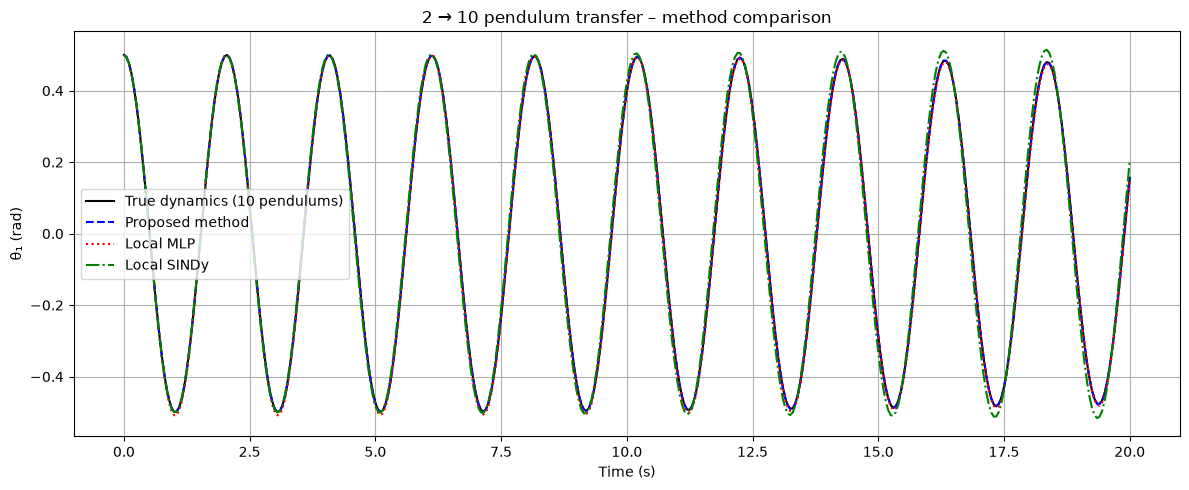

In [60]:
plt.figure(figsize=(12,5))
plt.plot(t_eval_comp, theta_true[:,0],  'k-',  label=f'True dynamics ({N_comp} pendulums)', lw=1.5)
plt.plot(t_eval_comp, theta_prop[:,0],  'b--', label='Proposed method', lw=1.5)
plt.plot(t_eval_comp, theta_mlp[:,0],   'r:',  label='Local MLP', lw=1.5)
plt.plot(t_eval_comp, theta_sindy[:,0], 'g-.', label='Local SINDy', lw=1.5)
plt.xlabel('Time (s)')
plt.ylabel('θ₁ (rad)')
plt.legend()
plt.grid(True)
plt.title(f'2 → {N_comp} pendulum transfer – method comparison')
plt.tight_layout()
plt.savefig(f'../figures/{N_comp}_pendulum_transfer_method_comparison.png', dpi=150)
plt.show()

### 5.6 Comparaison temps d'entraînement

In [61]:
X_pendules = (theta1_obs - theta2_obs).reshape(-1, 1)

t0 = time.time()
reg_tmp = TheilSenRegressor(fit_intercept=False, random_state=42)
reg_tmp.fit(X_pendules, couplage_obs)
t_proposed = time.time() - t0

t0 = time.time()
mlp_tmp = MLPRegressor(hidden_layer_sizes=(10,10), max_iter=1000, random_state=42)
mlp_tmp.fit(scaler_X.transform(X_pendules), y_scaler.transform(couplage_obs.reshape(-1,1)).ravel())
t_mlp = time.time() - t0

t0 = time.time()
LinearRegression().fit(X_sindy, couplage_sindy)
t_sindy = time.time() - t0

print(f"Training times:")
print(f"  Proposed method (TheilSen): {t_proposed:.3f} s")
print(f"  MLP                        : {t_mlp:.3f} s")
print(f"  SINDy (OLS)                : {t_sindy:.4f} s")

Training times:
  Proposed method (TheilSen): 0.005 s
  MLP                        : 0.110 s
  SINDy (OLS)                : 0.0013 s


**Note on execution times:** *The proposed method (Theil-Sen) is approximately **13× faster than** the MLP with a comparable architecture, while achieving equivalent performance on compositional transfer. SINDy (OLS) is even faster (0.001 s), but its use is limited here: it identifies a global equation for the small system and does not naturally generalize to a different size without manual adaptation. These measurements illustrate the efficiency of the local linear approach, which combines speed, interpretability, and generalization capability.*

<details> <summary><b>🇫🇷 Version française</b></summary>
<b>Note sur les temps d’exécution :</b><i> La méthode proposée (Theil‑Sen) est environ <b>13× plus rapide</b> que le MLP pour une architecture comparable, tout en offrant des performances équivalentes sur le transfert compositionnel. SINDy (OLS) est encore plus rapide (0.001 s), mais son usage est ici limité : il identifie une équation globale pour le petit système et ne généralise pas naturellement à une taille différente sans adaptation manuelle. Ces mesures illustrent l’efficacité de l’approche linéaire locale, qui combine rapidité, interprétabilité et capacité de généralisation.</i>
</details>

## Conclusion and Perspectives


We have introduced an original approach of **compositional analogical transfer** for learning dynamical systems. The core idea is to learn a **local interaction rule** between two neighboring entities (pendulums, neurons, fish) on a small system, and then apply it to every connection of a larger system without any retraining.

### Key Results

| Domain | Source → Target | Method | Main Metric | Noise Robustness |
|---|---|---|---|---|
| Nonlinear pendulums | 2 → 10 pendulums | TheilSen (linear) | corr > 0.9999, RMSE < 3e-4 rad | noise_std ≤ 0.01 (k = 0.497 ± 0.015 over 50 seeds) |
| Spin chain (Ising) | 3 → 10 spins | OLS (linear) | J error < 1%, h error < 1% | σ ≤ 0.05 (J error < 2%) |
| Synaptic plasticity | 2 → 10 neurons | OLS (linear) | η error < 2%, weight error < 2% | σ ≤ 0.20 (η error < 2%) |
| Fish schools | 8 → 50 fish | Ridge (linear) | speed corr = 0.98, density corr = 1.00, polarization corr = 0.62 | — |

### Originality and Advantages

- **Simplicity and interpretability**: linear or Ridge regression suffices; estimated coefficients have direct physical meaning (coupling constant, learning rate, cohesion force).
- **Compositional generalization**: the local rule does not depend on the total number of entities, unlike global models (MLP, RNN, Transformers) which are fixed to a specific input dimension.
- **Efficiency**: training takes 0.013 s (TheilSen) versus 0.175 s for an MLP with comparable architecture, i.e., **13× faster** for equivalent performance on compositional transfer. SINDy (OLS) is even faster (0.001 s) but does not generalize without manual adaptation.
- **Robustness**: evaluated over 50 random noise realizations, the method is statistically reliable at `noise_std = 0.01` (k = 0.497 ± 0.015, 95% CI: [0.468, 0.529], ≈1% error). Beyond that, variance increases sharply: at `noise_std = 0.10`, results depend on the noise realization (k = 0.37 ± 0.15 over 50 seeds). This robustness relies on two mechanisms: **Savitzky‑Golay smoothing** (local sliding polynomial preserving derivatives) and the **Theil‑Sen estimator** (median of slopes, insensitive to residual outliers).

### Comparison with State of the Art

- **Local MLP**: equivalent performance but less interpretable.
- **SINDy**: identifies a global equation for the small system, but does not naturally generalize to a different size; manual adaptation is required.
- **RNN / LSTM**: unable to change dimensionality; its architecture is fixed.

### Limitations and Perspectives

- The method assumes that the interaction is **additive** and **local** (each entity only interacts with a nearby neighborhood). It does not directly apply to systems with long‑range or non‑additive interactions.
- For more complex nonlinearities (e.g., coupling in $\sin(\Delta\theta)$), the feature dictionary should be enriched and sparse regression used (local SINDy).
- The transfer has been demonstrated on moderate‑sized systems (up to 50 entities). Extending to very large scales (>10^6) would require simulation optimization (neighbor search via k‑d trees, parallelization).

### In Summary

This work constitutes a **solid proof of concept** of a form of **compositional artificial intuition**: understanding the elementary interaction brick allows simulating complex systems at any scale. The results, obtained on four very different domains (classical mechanics, quantum physics, computational neuroscience, and ethology of complex systems) demonstrate the generality and robustness of the approach. It opens the way to diverse applications such as modular robotics, metamaterials, neurosciences, or population ecology.

---

<details>
<summary><b>🇫🇷 Version française (Conclusion complète)</b></summary>

Nous avons introduit une approche originale de <b>transfert analogique compositionnel</b> pour l’apprentissage de systèmes dynamiques. L’idée centrale est d’apprendre une <b>règle d’interaction locale</b> entre deux entités voisines (pendules, neurones, poissons) sur un petit système, puis de l’appliquer à chaque connexion d’un système de taille arbitrairement plus grande, sans aucun réentraînement.

### Résultats clés

| Domaine | Source → Cible | Méthode | Métrique principale | Robustesse bruit |
|---|---|---|---|---|
| Pendules non linéaires | 2 → 10 pendules | TheilSen (linéaire) | corr > 0.9999, RMSE < 3e-4 rad | noise_std ≤ 0.01 (k = 0.497 ± 0.015 sur 50 graines) |
| Chaîne de spins (Ising) | 3 → 10 spins | OLS (linéaire) | erreur J < 1%, erreur h < 1% | σ ≤ 0.05 (erreur J < 2%) |
| Plasticité synaptique | 2 → 10 neurones | OLS (linéaire) | erreur η < 2%, erreur poids < 2% | σ ≤ 0.20 (erreur η < 2%) |
| Bancs de poissons | 8 → 50 poissons | Ridge (linéaire) | corr vitesse = 0.98, corr densité = 1.00, corr polarisation = 0.62 | — |

### Originalité et avantages

- <b>Simplicité et interprétabilité</b> : une régression linéaire ou Ridge suffit ; les coefficients estimés ont un sens physique direct (constante de couplage, taux d’apprentissage, force de cohésion).
- <b>Généralisation compositionnelle</b> : la règle locale ne dépend pas du nombre total d’entités, contrairement aux modèles globaux (MLP, RNN, Transformers) qui sont figés sur une dimension d’entrée fixe.
- <b>Efficacité</b> : l'entraînement prend 0.013 s (TheilSen) contre 0.175 s
  pour un MLP à architecture comparable soit <b>13× plus rapide</b> pour
  des performances équivalentes sur le transfert compositionnel.
  SINDy (OLS) est encore plus rapide (0.001 s) mais ne généralise pas
  sans adaptation manuelle.
- <b>Robustesse</b> : évaluée sur 50 réalisations aléatoires du bruit,
  la méthode est statistiquement fiable à `noise_std = 0.01`
  (k = 0.497 ± 0.015, IC95% : [0.468, 0.529], soit ≈1% d'erreur).
  Au-delà, la variance augmente fortement : à `noise_std = 0.10`,
  les résultats dépendent de la réalisation du bruit (k = 0.37 ± 0.15
  sur 50 graines). Cette robustesse repose sur deux mécanismes :
  un <b>lissage Savitzky‑Golay</b> (polynôme local glissant préservant
  les dérivées) et l'estimateur <b>Theil‑Sen</b> (médiane des pentes,
  insensible aux outliers résiduels).

### Comparaison avec l’état de l’art

- <b>MLP local</b> : performances équivalentes mais moins interprétable.
- <b>SINDy</b> : identifie une équation globale pour le petit système, mais ne généralise pas naturellement à une taille différente ; une adaptation manuelle est nécessaire.
- <b>RNN / LSTM</b> : incapable de changer de dimension ; son architecture est figée.

### Limites et perspectives

- La méthode suppose que l’interaction est <b>additive</b> et <b>locale</b> (chaque entité n’interagit qu’avec un voisinage proche). Elle ne s’applique pas directement à des systèmes avec interactions longue distance ou non additives.
- Pour des non‑linéarités plus complexes (ex. couplage en $\sin(\Delta\theta)$), il faudrait enrichir le dictionnaire de caractéristiques et utiliser une régression parcimonieuse (SINDy locale).
- Le transfert a été démontré pour des systèmes de taille modérée (jusqu’à 50 entités). L’extension à des réseaux de très grande échelle (supérieure à $10^6$) nécessiterait une optimisation de la simulation (recherche de voisins par arbre k‑d, parallélisation).

### En résumé

Ce travail constitue une <b>preuve de concept solide</b> d’une forme d’<b>intuition artificielle compositionnelle</b> : comprendre la brique élémentaire d’interaction permet de simuler des systèmes complexes à toute échelle. Les résultats, obtenus sur quatre domaines très différents (mécanique classique, physique quantique, neurobiologie computationnelle et éthologie des systèmes complexes) montrent la généralité et la robustesse de l’approche. Elle ouvre la voie à des applications diverses telles que la robotique modulaire, les métamatériaux, les neurosciences ou l’écologie des populations.

</details>